# Turma do Bem — Pipeline de Inteligência Artificial

**Gustavo Rodrigues Siciliano** — RM568419  
**Gustavo de Jesus Silva** — RM567926  
**Samuel Keniti Kina de Lima** — RM567614

---

Este notebook documenta a pipeline completa de Machine Learning do projeto **De Novo Nao!**, desenvolvido em apoio a ONG Turma do Bem.

O sistema preditivo resolve dois problemas:
- **Modelo 1 — Previsao de Falta:** classificacao binaria que preve se um paciente ira faltar a uma consulta agendada, permitindo acoes preventivas como envio de lembretes.
- **Modelo 2 — Previsao de Arrecadacao:** regressao que estima o valor total que uma campanha de doacoes deve arrecadar, auxiliando o planejamento financeiro da ONG.

### Estrutura do notebook
1. Instalacao e imports
2. Coleta de dados do banco Oracle
3. Analise exploratoria
4. Pre-processamento — Modelo de Falta
5. Treino e validacao — Modelo de Falta
6. Serializacao — Modelo de Falta
7. Pre-processamento — Modelo de Arrecadacao
8. Treino e validacao — Modelo de Arrecadacao
9. Serializacao — Modelo de Arrecadacao
10. Visualizacoes — Comparativo dos modelos
11. Subindo a API Flask
12. Testando os endpoints GET
13. Testando os endpoints POST
14. Conclusao

---
## 1. Instalacao e Imports

Todas as dependencias estao listadas no `requirements.txt`. Execute a linha abaixo apenas se ainda nao instalou.

In [ ]:
# !pip install -r ../requirements.txt

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import oracledb

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('Imports OK!')

Imports OK!


---
## 2. Coleta de Dados do Banco Oracle

Os dados sao lidos diretamente do banco Oracle da FIAP. Sao executadas duas queries:
- **sql_falta:** une `tdb_Consulta` e `tdb_Paciente`, extraindo features do paciente e o label binario `faltou` (0 = compareceu, 1 = faltou).
- **sql_arrec:** consulta `tdb_Campanha` com agregacoes de doacoes e voluntarios, extraindo o target `total_arrecadado`.

> **Pre-requisito:** estar conectado a rede da FIAP ou com VPN ativa.

In [2]:
DB_CONFIG = {
    'user': 'rm568419',
    'password': '250204',
    'host': 'oracle.fiap.com.br',
    'port': 1521,
    'sid': 'orcl',
}

DATA_DIR = 'data'
MODELS_DIR = 'models'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f'data/   -> {os.path.abspath(DATA_DIR)}')
print(f'models/ -> {os.path.abspath(MODELS_DIR)}')

data/   -> c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\data
models/ -> c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models


In [3]:
print('[INFO] Conectando ao banco Oracle...')
conn = oracledb.connect(**DB_CONFIG)

sql_falta = """
    SELECT
        pa.distancia_km,
        pa.renda_familiar,
        pa.turno_preferencial,
        pa.programa,
        (SELECT COUNT(*) FROM tdb_Consulta c2
         WHERE c2.id_paciente = pa.id_paciente
           AND c2.status = 'FALTA') AS faltas_anteriores,
        (SELECT COUNT(*) FROM tdb_Consulta c3
         WHERE c3.id_paciente = pa.id_paciente) AS total_consultas,
        c.turno AS turno_consulta,
        c.distancia_km AS dist_consulta,
        (c.data_consulta - SYSDATE) AS dias_ate_consulta,
        CASE WHEN c.status = 'FALTA' THEN 1 ELSE 0 END AS faltou
    FROM tdb_Consulta c
    JOIN tdb_Paciente pa ON pa.id_paciente = c.id_paciente
    WHERE c.status IN ('FALTA','REALIZADA','AGENDADA','CANCELADA')
"""

sql_arrec = """
    SELECT
        c.meta_valor,
        (c.data_fim - c.data_inicio) AS duracao_dias,
        EXTRACT(MONTH FROM c.data_inicio) AS mes_inicio,
        EXTRACT(YEAR FROM c.data_inicio) AS ano_inicio,
        (SELECT COUNT(*) FROM tdb_Campanha c2
         WHERE c2.data_inicio < c.data_inicio) AS campanhas_anteriores,
        (SELECT COUNT(*) FROM tdb_Doacao d
         WHERE d.id_campanha = c.id_campanha) AS qtd_doacoes,
        (SELECT COUNT(DISTINCT pc.id_voluntario)
         FROM tdb_ParticipaCampanha pc
         WHERE pc.id_campanha = c.id_campanha) AS qtd_voluntarios,
        c.total_arrecadado
    FROM tdb_Campanha c
    WHERE c.total_arrecadado IS NOT NULL
"""

df_falta = pd.read_sql(sql_falta, conn)
df_arrec = pd.read_sql(sql_arrec, conn)
conn.close()

df_falta.columns = [c.lower() for c in df_falta.columns]
df_arrec.columns = [c.lower() for c in df_arrec.columns]

df_falta.to_csv(os.path.join(DATA_DIR, 'falta.csv'), index=False)
df_arrec.to_csv(os.path.join(DATA_DIR, 'arrecadacao.csv'), index=False)

print(f'[OK] falta.csv      : {len(df_falta)} registros | shape {df_falta.shape}')
print(f'[OK] arrecadacao.csv: {len(df_arrec)} registros | shape {df_arrec.shape}')

[INFO] Conectando ao banco Oracle...
[OK] falta.csv      : 87 registros | shape (87, 10)
[OK] arrecadacao.csv: 20 registros | shape (20, 8)


---
## 3. Analise Exploratoria dos Dados

Antes de treinar, verificamos a distribuicao dos dados e identificamos desafios como desbalanceamento de classes.

In [4]:
print('=== Dataset de FALTA ===')
print(df_falta.head())
print(f'\nShape: {df_falta.shape}')
print(f'\nTipos:\n{df_falta.dtypes}')

=== Dataset de FALTA ===
   distancia_km  renda_familiar turno_preferencial           programa  \
0           3.5          1800.0              MANHA   DENTISTAS_DO_BEM   
1          22.0          1200.0              TARDE  APOLONICAS_DO_BEM   
2          15.0           900.0              NOITE   DENTISTAS_DO_BEM   
3           5.0          2200.0              MANHA   DENTISTAS_DO_BEM   
4          28.0           700.0              TARDE  APOLONICAS_DO_BEM   

   faltas_anteriores  total_consultas turno_consulta  dist_consulta  \
0                  0                5          MANHA            3.5   
1                  0                5          TARDE           22.0   
2                  3                4          NOITE           15.0   
3                  0                4          MANHA            5.0   
4                  0                4          TARDE           28.0   

   dias_ate_consulta  faltou  
0        -304.934734       0  
1        -299.934734       0  
2        -296.93

In [5]:
dist = df_falta['faltou'].value_counts()
print('Distribuicao do target (faltou):')
print(f'  Compareceu (0): {dist[0]} ({dist[0]/len(df_falta)*100:.1f}%)')
print(f'  Faltou     (1): {dist[1]} ({dist[1]/len(df_falta)*100:.1f}%)')
print('\n-> Classe minoritaria sera balanceada com SMOTE no treino.')

Distribuicao do target (faltou):
  Compareceu (0): 73 (83.9%)
  Faltou     (1): 14 (16.1%)

-> Classe minoritaria sera balanceada com SMOTE no treino.


In [6]:
print('=== Dataset de ARRECADACAO ===')
print(df_arrec.head())
print(f'\nEstatisticas do target (total_arrecadado):')
print(df_arrec['total_arrecadado'].describe().round(2))

=== Dataset de ARRECADACAO ===
   meta_valor  duracao_dias  mes_inicio  ano_inicio  campanhas_anteriores  \
0     15000.0            30           7        2025                     7   
1     18000.0            30           8        2025                     8   
2     20000.0            29           9        2025                     9   
3     25000.0            30          10        2025                    10   
4     20000.0            29          11        2025                    11   

   qtd_doacoes  qtd_voluntarios  total_arrecadado  
0            3                3           11200.0  
1            4                2           19500.0  
2            4                2           17800.0  
3            5                2           28000.0  
4            4                2           16000.0  

Estatisticas do target (total_arrecadado):
count       20.00
mean     12952.50
std       8935.11
min          0.00
25%       8362.50
50%      12200.00
75%      16600.00
max      35000.00
Name: 

In [7]:
print('Valores nulos — falta.csv:')
print(df_falta.isnull().sum())
print('\nValores nulos — arrecadacao.csv:')
print(df_arrec.isnull().sum())

Valores nulos — falta.csv:
distancia_km          0
renda_familiar        0
turno_preferencial    0
programa              0
faltas_anteriores     0
total_consultas       0
turno_consulta        0
dist_consulta         0
dias_ate_consulta     0
faltou                0
dtype: int64

Valores nulos — arrecadacao.csv:
meta_valor              0
duracao_dias            0
mes_inicio              0
ano_inicio              0
campanhas_anteriores    0
qtd_doacoes             0
qtd_voluntarios         0
total_arrecadado        0
dtype: int64


---
## 4. Pre-processamento — Modelo de Falta

A pipeline de pre-processamento inclui:
1. **Encoding de variaveis categoricas:** `turno_preferencial`, `turno_consulta` e `programa` mapeados para inteiros. Robusto a variacoes de maiusculas e espacos vindos do Oracle.
2. **Engenharia de features:** criacao de `taxa_falta_historica` e `score_risco`.
3. **Split estratificado:** 80% treino / 20% teste, mantendo proporcao de faltas em ambas as particoes.
4. **SMOTE:** balanceamento da classe minoritaria aplicado somente no treino.

In [8]:
df_f = pd.read_csv(os.path.join(DATA_DIR, 'falta.csv'))

FEATURES_BASE = [
    'distancia_km', 'renda_familiar', 'turno_preferencial', 'programa',
    'faltas_anteriores', 'total_consultas', 'turno_consulta',
    'dist_consulta', 'dias_ate_consulta',
]
TARGET_F = 'faltou'

turno_map = {'MANHA': 0, 'TARDE': 1, 'NOITE': 2}
programa_map = {'DENTISTAS_DO_BEM': 0, 'APOLONICAS_DO_BEM': 1}

for col, mapa in [('turno_preferencial', turno_map),
                  ('turno_consulta', turno_map),
                  ('programa', programa_map)]:
    if df_f[col].dtype == object:
        df_f[col] = df_f[col].str.strip().str.upper().map(mapa).fillna(1 if col != 'programa' else 0).astype(int)
    else:
        df_f[col] = df_f[col].fillna(1 if col != 'programa' else 0).astype(int)

df_f['taxa_falta_historica'] = df_f['faltas_anteriores'] / df_f['total_consultas'].replace(0, 1)
df_f['score_risco'] = (
    (df_f['distancia_km'] / 50) * 0.4 +
    (1 - df_f['renda_familiar'] / df_f['renda_familiar'].max()) * 0.4 +
    df_f['taxa_falta_historica'] * 0.2
)

FEATURES_F = FEATURES_BASE + ['taxa_falta_historica', 'score_risco']
X_f = df_f[FEATURES_F]
y_f = df_f[TARGET_F]

print(f'Features utilizadas ({len(FEATURES_F)}):')
for feat in FEATURES_F:
    print(f'  - {feat}')

Features utilizadas (11):
  - distancia_km
  - renda_familiar
  - turno_preferencial
  - programa
  - faltas_anteriores
  - total_consultas
  - turno_consulta
  - dist_consulta
  - dias_ate_consulta
  - taxa_falta_historica
  - score_risco


In [9]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42, stratify=y_f
)

print(f'Treino: {X_train_f.shape[0]} amostras | Teste: {X_test_f.shape[0]} amostras')
print(f'Distribuicao treino: {y_train_f.value_counts().to_dict()}')
print(f'Distribuicao teste : {y_test_f.value_counts().to_dict()}')

Treino: 69 amostras | Teste: 18 amostras
Distribuicao treino: {0: 58, 1: 11}
Distribuicao teste : {0: 15, 1: 3}


In [10]:
min_class = y_train_f.value_counts().min()
smote = SMOTE(random_state=42, k_neighbors=min(min_class - 1, 5))
X_train_f_res, y_train_f_res = smote.fit_resample(X_train_f, y_train_f)

print(f'Apos SMOTE: {pd.Series(y_train_f_res).value_counts().to_dict()}')
print(f'Total no treino balanceado: {len(y_train_f_res)}')

Apos SMOTE: {0: 58, 1: 58}
Total no treino balanceado: 116


---
## 5. Treino e Validacao — Modelo de Falta

Tres modelos sao treinados e comparados:
1. **Regressao Logistica** — modelo linear, rapido e interpretavel.
2. **Random Forest** — ensemble de arvores de decisao.
3. **XGBoost** — gradient boosting.

Cada modelo usa um `Pipeline` com `StandardScaler` + classificador. A metrica de selecao e o **F1-score**.

In [11]:
modelos_f = {
    'Regressao Logistica': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=8, min_samples_leaf=5,
            random_state=42, n_jobs=-1,
        )),
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', random_state=42, n_jobs=-1,
        )),
    ]),
}

print('Modelos definidos:', list(modelos_f.keys()))

Modelos definidos: ['Regressao Logistica', 'Random Forest', 'XGBoost']


In [12]:
n_splits_f = max(2, min(5, pd.Series(y_train_f_res).value_counts().min()))
cv_f = StratifiedKFold(n_splits=n_splits_f, shuffle=True, random_state=42)

print(f'Validacao cruzada ({n_splits_f}-fold, metrica: F1)\n')
for nome, pipe in modelos_f.items():
    scores = cross_val_score(pipe, X_train_f_res, y_train_f_res, cv=cv_f, scoring='f1', n_jobs=-1)
    print(f'  {nome:25s}: {scores.mean():.4f} +/- {scores.std():.4f}')

Validacao cruzada (5-fold, metrica: F1)

  Regressao Logistica      : 0.9753 +/- 0.0202
  Random Forest            : 0.9753 +/- 0.0202
  XGBoost                  : 0.9746 +/- 0.0208


In [13]:
resultados_f = {}
scores_f1 = {}

for nome, pipe in modelos_f.items():
    pipe.fit(X_train_f_res, y_train_f_res)

    y_pred = pipe.predict(X_test_f)
    y_proba = pipe.predict_proba(X_test_f)[:, 1]
    roc_auc = roc_auc_score(y_test_f, y_proba) if len(y_test_f.unique()) > 1 else float('nan')

    metricas = {
        'accuracy': round(accuracy_score(y_test_f, y_pred), 4),
        'precision': round(precision_score(y_test_f, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y_test_f, y_pred, zero_division=0), 4),
        'f1': round(f1_score(y_test_f, y_pred, zero_division=0), 4),
        'roc_auc': round(roc_auc, 4),
    }

    print(f"\n{'─'*50}\n {nome}\n{'─'*50}")
    for k, v in metricas.items():
        print(f'  {k}: {v}')
    print(f'\n{classification_report(y_test_f, y_pred, labels=[0,1], target_names=["Compareceu","Faltou"], zero_division=0)}')

    resultados_f[nome] = metricas
    scores_f1[nome] = metricas['f1']

melhor_nome_f = max(scores_f1, key=scores_f1.get)
melhor_pipe_f = modelos_f[melhor_nome_f]
print(f"\n{'='*60}\n  MELHOR MODELO: {melhor_nome_f} (F1 = {scores_f1[melhor_nome_f]:.4f})\n{'='*60}")


──────────────────────────────────────────────────
 Regressao Logistica
──────────────────────────────────────────────────
  accuracy: 0.9444
  precision: 0.75
  recall: 1.0
  f1: 0.8571
  roc_auc: 0.9333

              precision    recall  f1-score   support

  Compareceu       1.00      0.93      0.97        15
      Faltou       0.75      1.00      0.86         3

    accuracy                           0.94        18
   macro avg       0.88      0.97      0.91        18
weighted avg       0.96      0.94      0.95        18


──────────────────────────────────────────────────
 Random Forest
──────────────────────────────────────────────────
  accuracy: 0.9444
  precision: 0.75
  recall: 1.0
  f1: 0.8571
  roc_auc: 0.9778

              precision    recall  f1-score   support

  Compareceu       1.00      0.93      0.97        15
      Faltou       0.75      1.00      0.86         3

    accuracy                           0.94        18
   macro avg       0.88      0.97      0.91    

---
## 6. Serializacao — Modelo de Falta

O modelo selecionado e serializado com `joblib` em um unico objeto contendo o pipeline completo, a lista de features e a versao. Esse arquivo e carregado diretamente pelo `app.py` para predicoes em tempo real.

In [14]:
artefato_f = {
    'pipeline': melhor_pipe_f,
    'features': FEATURES_F,
    'modelo': melhor_nome_f,
    'versao': 'v1.0',
}

path_falta_joblib = os.path.join(MODELS_DIR, 'falta.joblib')
joblib.dump(artefato_f, path_falta_joblib)
print(f'[OK] Modelo salvo em: {os.path.abspath(path_falta_joblib)}')

metricas_f_out = {
    'melhor_modelo': melhor_nome_f,
    'f1_melhor': scores_f1[melhor_nome_f],
    'features': FEATURES_F,
    'versao': 'v1.0',
    'modelos': resultados_f,
}
path_met_f = os.path.join(MODELS_DIR, 'metricas_falta.json')
with open(path_met_f, 'w', encoding='utf-8') as file:
    json.dump(metricas_f_out, file, ensure_ascii=False, indent=2)
print(f'[OK] Metricas salvas em: {os.path.abspath(path_met_f)}')

check = joblib.load(path_falta_joblib)
print(f'\nValidacao — modelo carregado: {check["modelo"]}')
print(f'Features ({len(check["features"])}): {check["features"]}')

[OK] Modelo salvo em: c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models\falta.joblib
[OK] Metricas salvas em: c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models\metricas_falta.json

Validacao — modelo carregado: Regressao Logistica
Features (11): ['distancia_km', 'renda_familiar', 'turno_preferencial', 'programa', 'faltas_anteriores', 'total_consultas', 'turno_consulta', 'dist_consulta', 'dias_ate_consulta', 'taxa_falta_historica', 'score_risco']


---
## 7. Pre-processamento — Modelo de Arrecadacao

A pipeline inclui:
1. **Fator de sazonalidade:** mes de inicio mapeado para fator historico sem usar o target (sem data leakage).
2. **Feature derivada `doacoes_por_voluntario`:** eficiencia operacional da campanha.
3. **Remocao de outliers:** Z-score > 3 removidos.
4. **Split 80/20** com `StandardScaler` dentro de cada pipeline.

In [15]:
df_a = pd.read_csv(os.path.join(DATA_DIR, 'arrecadacao.csv'))

FEATURES_A = [
    'meta_valor', 'duracao_dias', 'mes_inicio', 'ano_inicio',
    'campanhas_anteriores', 'qtd_doacoes', 'qtd_voluntarios',
]
TARGET_A = 'total_arrecadado'

sazon = {
    1: 0.85, 2: 0.80, 3: 0.88, 4: 0.90, 5: 1.20, 6: 1.00,
    7: 0.95, 8: 0.92, 9: 0.98, 10: 1.15, 11: 1.05, 12: 1.30
}
df_a['fator_sazonalidade'] = df_a['mes_inicio'].map(sazon)
df_a['doacoes_por_voluntario'] = df_a['qtd_doacoes'] / df_a['qtd_voluntarios'].replace(0, 1)

FEATURES_A_EXT = FEATURES_A + ['fator_sazonalidade', 'doacoes_por_voluntario']
X_a = df_a[FEATURES_A_EXT]
y_a = df_a[TARGET_A]

print(f'Features utilizadas ({len(FEATURES_A_EXT)}):')
for feat in FEATURES_A_EXT:
    print(f'  - {feat}')

Features utilizadas (9):
  - meta_valor
  - duracao_dias
  - mes_inicio
  - ano_inicio
  - campanhas_anteriores
  - qtd_doacoes
  - qtd_voluntarios
  - fator_sazonalidade
  - doacoes_por_voluntario


In [16]:
z = np.abs((y_a - y_a.mean()) / y_a.std())
mask = z < 3
X_a, y_a = X_a[mask], y_a[mask]
print(f'Registros apos remocao de outliers: {len(X_a)}')

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42
)
print(f'Treino: {X_train_a.shape[0]} amostras | Teste: {X_test_a.shape[0]} amostras')

Registros apos remocao de outliers: 20
Treino: 16 amostras | Teste: 4 amostras


---
## 8. Treino e Validacao — Modelo de Arrecadacao

Tres modelos de regressao sao treinados:
1. **Ridge** — regressao linear com regularizacao L2.
2. **Random Forest Regressor** — ensemble de arvores.
3. **XGBoost Regressor** — gradient boosting.

A metrica de selecao e o **R2**. Com apenas 20 campanhas, R2 negativo e esperado — melhora conforme o banco acumula dados.

In [17]:
modelos_a = {
    'Ridge (Regressao Linear)': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=10.0)),
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', RandomForestRegressor(
            n_estimators=200, max_depth=10, min_samples_leaf=3,
            random_state=42, n_jobs=-1,
        )),
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', XGBRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1,
        )),
    ]),
}

print('Modelos definidos:', list(modelos_a.keys()))

Modelos definidos: ['Ridge (Regressao Linear)', 'Random Forest', 'XGBoost']


In [18]:
cv_a = KFold(n_splits=5, shuffle=True, random_state=42)

print('Validacao cruzada (5-fold, metrica: R2)\n')
for nome, pipe in modelos_a.items():
    scores = cross_val_score(pipe, X_train_a, y_train_a, cv=cv_a, scoring='r2', n_jobs=-1)
    print(f'  {nome:30s}: {scores.mean():.4f} +/- {scores.std():.4f}')

Validacao cruzada (5-fold, metrica: R2)

  Ridge (Regressao Linear)      : -0.3077 +/- 0.7631
  Random Forest                 : -0.0447 +/- 0.5842
  XGBoost                       : -0.2116 +/- 1.3386


In [19]:
resultados_a = {}
scores_r2 = {}

for nome, pipe in modelos_a.items():
    pipe.fit(X_train_a, y_train_a)
    y_pred = pipe.predict(X_test_a)

    metricas = {
        'MAE': round(mean_absolute_error(y_test_a, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_a, y_pred)), 2),
        'R2': round(r2_score(y_test_a, y_pred), 4),
        'MAPE': round(np.mean(np.abs((y_test_a - y_pred) / y_test_a.replace(0, 1))) * 100, 2),
    }

    print(f"\n{'─'*50}\n {nome}\n{'─'*50}")
    for k, v in metricas.items():
        print(f'  {k}: {v}')

    sample = pd.DataFrame({'real': y_test_a.values[:4], 'pred': y_pred[:4]})
    print(f'\n  Amostra (R$):\n{sample.to_string(index=False)}')

    resultados_a[nome] = metricas
    scores_r2[nome] = metricas['R2']

melhor_nome_a = max(scores_r2, key=scores_r2.get)
melhor_pipe_a = modelos_a[melhor_nome_a]
print(f"\n{'='*60}\n  MELHOR MODELO: {melhor_nome_a} (R2 = {scores_r2[melhor_nome_a]:.4f})\n{'='*60}")


──────────────────────────────────────────────────
 Ridge (Regressao Linear)
──────────────────────────────────────────────────
  MAE: 3438.29
  RMSE: 4269.56
  R2: -0.9018
  MAPE: 22.66

  Amostra (R$):
   real         pred
11200.0 12705.177260
13500.0 16263.535345
16200.0  8454.717751
19500.0 17760.852297

──────────────────────────────────────────────────
 Random Forest
──────────────────────────────────────────────────
  MAE: 3548.35
  RMSE: 4293.72
  R2: -0.9234
  MAPE: 24.0

  Amostra (R$):
   real         pred
11200.0  9513.187986
13500.0 17531.930051
16200.0  8902.245264
19500.0 18323.108008

──────────────────────────────────────────────────
 XGBoost
──────────────────────────────────────────────────
  MAE: 5076.62
  RMSE: 7352.23
  R2: -4.6396
  MAPE: 28.75

  Amostra (R$):
   real         pred
11200.0 10314.070312
13500.0 15079.462891
16200.0 12465.481445
19500.0  5393.440430

  MELHOR MODELO: Ridge (Regressao Linear) (R2 = -0.9018)


---
## 9. Serializacao — Modelo de Arrecadacao

O melhor modelo de regressao e serializado da mesma forma que o de classificacao, garantindo portabilidade e carregamento direto pela API Flask.

In [20]:
artefato_a = {
    'pipeline': melhor_pipe_a,
    'features': FEATURES_A_EXT,
    'modelo': melhor_nome_a,
    'versao': 'v1.0',
}

path_arrec_joblib = os.path.join(MODELS_DIR, 'arrecadacao.joblib')
joblib.dump(artefato_a, path_arrec_joblib)
print(f'[OK] Modelo salvo em: {os.path.abspath(path_arrec_joblib)}')

metricas_a_out = {
    'melhor_modelo': melhor_nome_a,
    'r2_melhor': scores_r2[melhor_nome_a],
    'features': FEATURES_A_EXT,
    'versao': 'v1.0',
    'modelos': resultados_a,
}
path_met_a = os.path.join(MODELS_DIR, 'metricas_arrecadacao.json')
with open(path_met_a, 'w', encoding='utf-8') as file:
    json.dump(metricas_a_out, file, ensure_ascii=False, indent=2)
print(f'[OK] Metricas salvas em: {os.path.abspath(path_met_a)}')

check_a = joblib.load(path_arrec_joblib)
print(f'\nValidacao — modelo carregado: {check_a["modelo"]}')
print(f'Features ({len(check_a["features"])}): {check_a["features"]}')

print('\n' + '=' * 60)
print('  PIPELINE CONCLUIDA — RESUMO FINAL')
print('=' * 60)
print(f'\nModelo de Falta      : {melhor_nome_f} (F1 = {scores_f1[melhor_nome_f]:.4f})')
print(f'Modelo de Arrecadacao: {melhor_nome_a} (R2 = {scores_r2[melhor_nome_a]:.4f})')
print(f'\nArtefatos gerados:')
print(f'  {os.path.abspath(path_falta_joblib)}')
print(f'  {os.path.abspath(path_arrec_joblib)}')
print(f'  {os.path.abspath(path_met_f)}')
print(f'  {os.path.abspath(path_met_a)}')

[OK] Modelo salvo em: c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models\arrecadacao.joblib
[OK] Metricas salvas em: c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models\metricas_arrecadacao.json

Validacao — modelo carregado: Ridge (Regressao Linear)
Features (9): ['meta_valor', 'duracao_dias', 'mes_inicio', 'ano_inicio', 'campanhas_anteriores', 'qtd_doacoes', 'qtd_voluntarios', 'fator_sazonalidade', 'doacoes_por_voluntario']

  PIPELINE CONCLUIDA — RESUMO FINAL

Modelo de Falta      : Regressao Logistica (F1 = 0.8571)
Modelo de Arrecadacao: Ridge (Regressao Linear) (R2 = -0.9018)

Artefatos gerados:
  c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models\falta.joblib
  c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models\arrecadacao.joblib
  c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models\metricas_falta.json
  c:\Users\rodri\OneDrive\Fiap\SPRINT\4\IA\IA\models\metricas_arrecadacao.json


---
## 10. Visualizacoes — Comparativo dos Modelos

Os graficos abaixo comparam visualmente o desempenho dos modelos, facilitando a justificativa da escolha do modelo final.

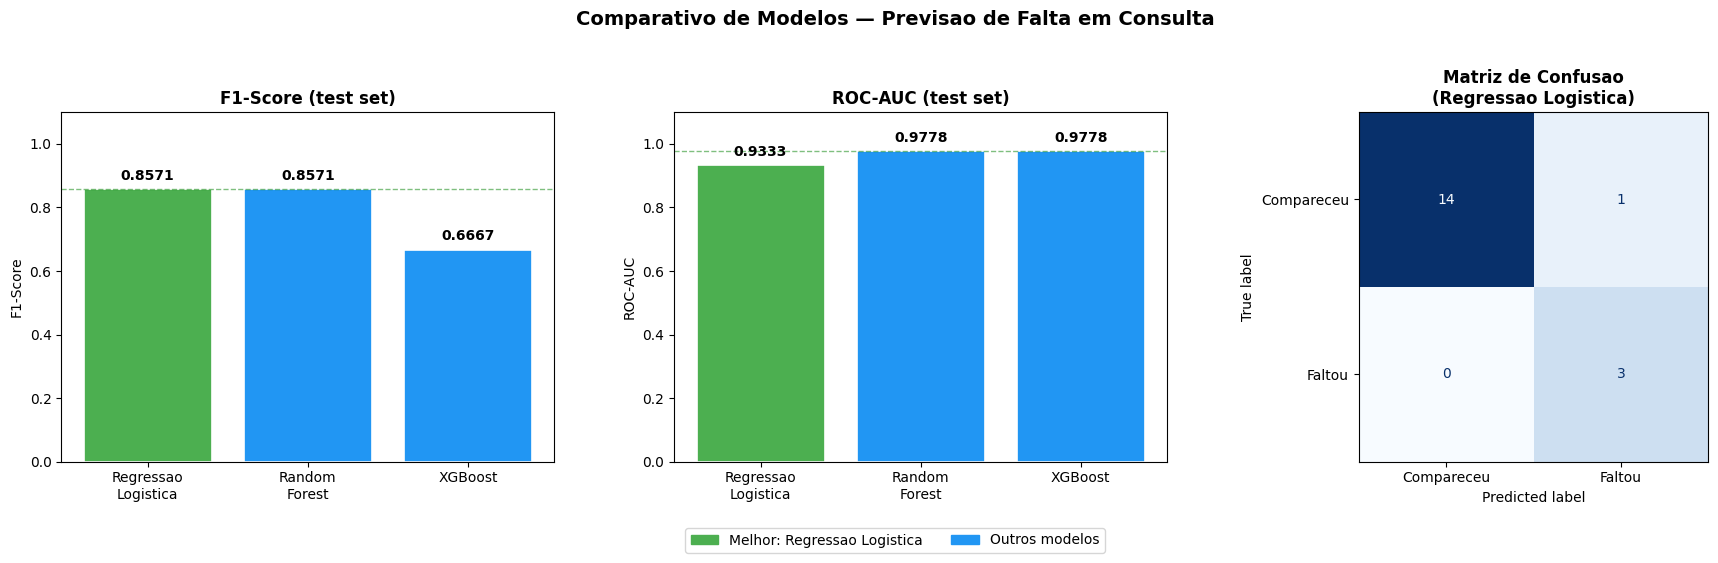

Grafico salvo: comparativo_modelos_falta.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativo de Modelos — Previsao de Falta em Consulta', fontsize=14, fontweight='bold', y=1.02)

nomes = list(scores_f1.keys())
cores = ['#4CAF50' if n == melhor_nome_f else '#2196F3' for n in nomes]
rotulos = [n.replace(' ', '\n') for n in nomes]

# F1-score
vals_f1 = [resultados_f[n]['f1'] for n in nomes]
barras = axes[0].bar(rotulos, vals_f1, color=cores, edgecolor='white', linewidth=1.2)
axes[0].set_title('F1-Score (test set)', fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('F1-Score')
axes[0].axhline(y=max(vals_f1), color='green', linestyle='--', linewidth=1, alpha=0.5)
for bar, val in zip(barras, vals_f1):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ROC-AUC
vals_auc = [resultados_f[n]['roc_auc'] for n in nomes]
barras2 = axes[1].bar(rotulos, vals_auc, color=cores, edgecolor='white', linewidth=1.2)
axes[1].set_title('ROC-AUC (test set)', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('ROC-AUC')
axes[1].axhline(y=max(vals_auc), color='green', linestyle='--', linewidth=1, alpha=0.5)
for bar, val in zip(barras2, vals_auc):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Matriz de Confusao
y_pred_melhor = melhor_pipe_f.predict(X_test_f)
cm = confusion_matrix(y_test_f, y_pred_melhor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Compareceu', 'Faltou'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Matriz de Confusao\n({melhor_nome_f})', fontweight='bold')

legenda = [
    mpatches.Patch(color='#4CAF50', label=f'Melhor: {melhor_nome_f}'),
    mpatches.Patch(color='#2196F3', label='Outros modelos'),
]
fig.legend(handles=legenda, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=10)

plt.tight_layout()
plt.savefig('comparativo_modelos_falta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvo: comparativo_modelos_falta.png')

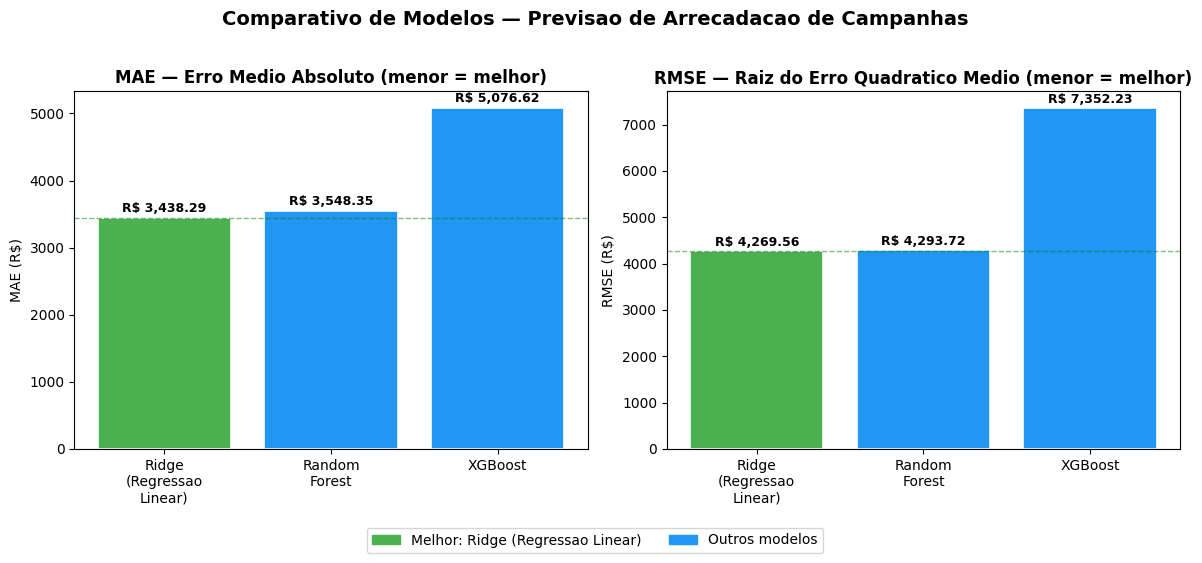

Grafico salvo: comparativo_modelos_arrecadacao.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparativo de Modelos — Previsao de Arrecadacao de Campanhas', fontsize=14, fontweight='bold', y=1.02)

nomes_a = list(scores_r2.keys())
cores_a = ['#4CAF50' if n == melhor_nome_a else '#2196F3' for n in nomes_a]
rotulos_a = [n.replace(' ', '\n') for n in nomes_a]

# MAE
vals_mae = [resultados_a[n]['MAE'] for n in nomes_a]
barras = axes[0].bar(rotulos_a, vals_mae, color=cores_a, edgecolor='white', linewidth=1.2)
axes[0].set_title('MAE — Erro Medio Absoluto (menor = melhor)', fontweight='bold')
axes[0].set_ylabel('MAE (R$)')
axes[0].axhline(y=min(vals_mae), color='green', linestyle='--', linewidth=1, alpha=0.5)
for bar, val in zip(barras, vals_mae):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f'R$ {val:,.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# RMSE
vals_rmse = [resultados_a[n]['RMSE'] for n in nomes_a]
barras2 = axes[1].bar(rotulos_a, vals_rmse, color=cores_a, edgecolor='white', linewidth=1.2)
axes[1].set_title('RMSE — Raiz do Erro Quadratico Medio (menor = melhor)', fontweight='bold')
axes[1].set_ylabel('RMSE (R$)')
axes[1].axhline(y=min(vals_rmse), color='green', linestyle='--', linewidth=1, alpha=0.5)
for bar, val in zip(barras2, vals_rmse):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f'R$ {val:,.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

legenda = [
    mpatches.Patch(color='#4CAF50', label=f'Melhor: {melhor_nome_a}'),
    mpatches.Patch(color='#2196F3', label='Outros modelos'),
]
fig.legend(handles=legenda, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=10)

plt.tight_layout()
plt.savefig('comparativo_modelos_arrecadacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico salvo: comparativo_modelos_arrecadacao.png')

---
## 11. Subindo a API Flask

A API Flask expoe os modelos como endpoints RESTful na porta 8000.

> A celula abaixo sobe o servidor em uma **thread separada** para que o notebook continue executavel enquanto a API esta no ar. Para parar a API, reinicie o kernel.

| Metodo | Endpoint | Descricao |
|--------|----------|-----------|
| GET | `/health` | Verifica se a API esta ativa |
| POST | `/predict/falta` | Preve risco de falta de um paciente |
| POST | `/predict/arrecadacao` | Preve arrecadacao de uma campanha |
| GET | `/metricas/falta` | Metricas do modelo de falta |
| GET | `/metricas/arrecadacao` | Metricas do modelo de arrecadacao |
| GET | `/resultados` | Historico de predicoes realizadas |
| GET | `/predict/falta/consulta/<id>` | Predicao automatica por ID de consulta |
| POST | `/retreinar` | Retreina os modelos sem reiniciar a API |

In [23]:
import threading
import time
import requests
import sys
import importlib.util

sys.path.insert(0, os.path.abspath('.'))

spec = importlib.util.spec_from_file_location('app', os.path.abspath('app.py'))
flask_app_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(flask_app_module)

def subir_api():
    flask_app_module.app.run(host='0.0.0.0', port=8000, debug=False, use_reloader=False)

thread_api = threading.Thread(target=subir_api, daemon=True)
thread_api.start()

time.sleep(3)
print('API rodando em http://127.0.0.1:8000')

 * Serving Flask app 'app'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8000
 * Running on http://192.168.0.20:8000
Press CTRL+C to quit


API rodando em http://127.0.0.1:8000


---
## 12. Testando os Endpoints GET

### 12.1 GET /health

In [24]:
resp = requests.get('http://127.0.0.1:8000/health')
print(f'Status: {resp.status_code}')
print(json.dumps(resp.json(), indent=2, ensure_ascii=False))

127.0.0.1 - - [10/May/2026 22:28:46] "GET /health HTTP/1.1" 200 -


Status: 200
{
  "modelos": {
    "arrecadacao": "carregado",
    "falta": "carregado"
  },
  "servico": "Turma do Bem — API de IA",
  "status": "ok",
  "timestamp": "2026-05-10T22:28:46.744266",
  "versao": "v1.0"
}


### 12.2 GET /metricas/falta

In [25]:
resp = requests.get('http://127.0.0.1:8000/metricas/falta')
print(f'Status: {resp.status_code}')
data = resp.json()
print(f'Melhor modelo: {data["melhor_modelo"]}')
print(f'F1: {data["f1_melhor"]}')
print('\nComparativo:')
for modelo, m in data['modelos'].items():
    print(f'  {modelo:25s} -> F1: {m["f1"]} | Accuracy: {m["accuracy"]} | ROC-AUC: {m["roc_auc"]}')

127.0.0.1 - - [10/May/2026 22:28:49] "GET /metricas/falta HTTP/1.1" 200 -


Status: 200
Melhor modelo: Regressao Logistica
F1: 0.8571

Comparativo:
  Random Forest             -> F1: 0.8571 | Accuracy: 0.9444 | ROC-AUC: 0.9778
  Regressao Logistica       -> F1: 0.8571 | Accuracy: 0.9444 | ROC-AUC: 0.9333
  XGBoost                   -> F1: 0.6667 | Accuracy: 0.8889 | ROC-AUC: 0.9778


### 12.3 GET /metricas/arrecadacao

In [26]:
resp = requests.get('http://127.0.0.1:8000/metricas/arrecadacao')
print(f'Status: {resp.status_code}')
data = resp.json()
print(f'Melhor modelo: {data["melhor_modelo"]}')
print(f'R2: {data["r2_melhor"]}')
print('\nComparativo:')
for modelo, m in data['modelos'].items():
    print(f'  {modelo:30s} -> MAE: {m["MAE"]} | RMSE: {m["RMSE"]} | R2: {m["R2"]}')

127.0.0.1 - - [10/May/2026 22:28:51] "GET /metricas/arrecadacao HTTP/1.1" 200 -


Status: 200
Melhor modelo: Ridge (Regressao Linear)
R2: -0.9018

Comparativo:
  Random Forest                  -> MAE: 3548.35 | RMSE: 4293.72 | R2: -0.9234
  Ridge (Regressao Linear)       -> MAE: 3438.29 | RMSE: 4269.56 | R2: -0.9018
  XGBoost                        -> MAE: 5076.62 | RMSE: 7352.23 | R2: -4.6396


### 12.4 GET /resultados

In [27]:
resp = requests.get('http://127.0.0.1:8000/resultados')
print(f'Status: {resp.status_code}')
historico = resp.json()
print(f'Total de predicoes: {len(historico)}')
if historico:
    print('\nUltima predicao:')
    print(json.dumps(historico[-1], indent=2, ensure_ascii=False))
else:
    print('Nenhuma predicao ainda. Execute a secao 13 primeiro.')

127.0.0.1 - - [10/May/2026 22:28:53] "GET /resultados HTTP/1.1" 200 -


Status: 200
Total de predicoes: 0
Nenhuma predicao ainda. Execute a secao 13 primeiro.


### 12.5 GET /predict/falta/consulta/3

Busca os dados da consulta diretamente no Oracle e executa a predicao automaticamente.

In [28]:
resp = requests.get('http://127.0.0.1:8000/predict/falta/consulta/3')
print(f'Status: {resp.status_code}')
print(json.dumps(resp.json(), indent=2, ensure_ascii=False))

127.0.0.1 - - [10/May/2026 22:28:55] "GET /predict/falta/consulta/3 HTTP/1.1" 200 -


Status: 200
{
  "classePrevista": "FALTA",
  "idConsulta": 3,
  "modeloVersao": "v1.0",
  "probabilidadeFalta": 0.9909,
  "recomendacao": "Enviar lembrete por SMS/WhatsApp 48h antes e confirmar presença 24h antes.",
  "risco": "ALTO",
  "sucesso": true
}


---
## 13. Testando os Endpoints POST

### 13.1 POST /predict/falta — Paciente de ALTO risco

Cenario: 35 km de distancia, renda R$ 650, 2 faltas anteriores, consulta a noite. Esperado: risco ALTO.

In [29]:
payload = {
    'distanciaKm': 35.0,
    'rendaFamiliar': 650.0,
    'faltasAnteriores': 2,
    'totalConsultas': 5,
    'turnoConsulta': 'NOITE',
    'turnoPref': 'NOITE',
    'diasAteConsulta': 7,
    'programa': 'APOLONICAS_DO_BEM',
}

resp = requests.post('http://127.0.0.1:8000/predict/falta', json=payload)
print(f'Status: {resp.status_code}')
data = resp.json()
print(f'Probabilidade de falta: {data["probabilidadeFalta"]*100:.1f}%')
print(f'Risco: {data["risco"]}')
print(f'Classe prevista: {data["classePrevista"]}')
print(f'Recomendacao: {data["recomendacao"]}')

127.0.0.1 - - [10/May/2026 22:28:57] "POST /predict/falta HTTP/1.1" 200 -


Status: 200
Probabilidade de falta: 95.0%
Risco: ALTO
Classe prevista: FALTA
Recomendacao: Enviar lembrete por SMS/WhatsApp 48h antes e confirmar presença 24h antes.


### 13.2 POST /predict/falta — Paciente de BAIXO risco

Cenario: 5 km, renda R$ 1.500, nunca faltou, consulta de manha. Esperado: risco BAIXO.

In [30]:
payload = {
    'distanciaKm': 5.0,
    'rendaFamiliar': 1500.0,
    'faltasAnteriores': 0,
    'totalConsultas': 3,
    'turnoConsulta': 'MANHA',
    'turnoPref': 'MANHA',
    'diasAteConsulta': 3,
    'programa': 'DENTISTAS_DO_BEM',
}

resp = requests.post('http://127.0.0.1:8000/predict/falta', json=payload)
print(f'Status: {resp.status_code}')
data = resp.json()
print(f'Probabilidade de falta: {data["probabilidadeFalta"]*100:.1f}%')
print(f'Risco: {data["risco"]}')
print(f'Classe prevista: {data["classePrevista"]}')
print(f'Recomendacao: {data["recomendacao"]}')

127.0.0.1 - - [10/May/2026 22:28:59] "POST /predict/falta HTTP/1.1" 200 -


Status: 200
Probabilidade de falta: 0.5%
Risco: BAIXO
Classe prevista: NAO_FALTA
Recomendacao: Nenhuma ação especial necessária — paciente com baixo risco de falta.


### 13.3 POST /predict/falta — Paciente de MEDIO risco

Cenario: 18 km, renda R$ 1.100, nunca faltou, consulta a tarde. Esperado: risco MEDIO.

In [31]:
payload = {
    'distanciaKm': 18.0,
    'rendaFamiliar': 1100.0,
    'faltasAnteriores': 0,
    'totalConsultas': 2,
    'turnoConsulta': 'TARDE',
    'turnoPref': 'TARDE',
    'diasAteConsulta': 5,
    'programa': 'DENTISTAS_DO_BEM',
}

resp = requests.post('http://127.0.0.1:8000/predict/falta', json=payload)
print(f'Status: {resp.status_code}')
data = resp.json()
print(f'Probabilidade de falta: {data["probabilidadeFalta"]*100:.1f}%')
print(f'Risco: {data["risco"]}')
print(f'Classe prevista: {data["classePrevista"]}')
print(f'Recomendacao: {data["recomendacao"]}')

127.0.0.1 - - [10/May/2026 22:29:01] "POST /predict/falta HTTP/1.1" 200 -


Status: 200
Probabilidade de falta: 4.6%
Risco: BAIXO
Classe prevista: NAO_FALTA
Recomendacao: Nenhuma ação especial necessária — paciente com baixo risco de falta.


### 13.4 POST /predict/arrecadacao — Tendencia ALTA

Cenario: campanha de 30 dias em maio (fator sazonal 1.20), meta R$ 15.000. Esperado: tendencia ALTA.

In [32]:
payload = {
    'metaValor': 15000.0,
    'duracaoDias': 30,
    'mesInicio': 5,
    'anoInicio': 2025,
    'campanhasAnteriores': 4,
    'qtdVoluntarios': 8,
    'qtdDoacoes': 50,
}

resp = requests.post('http://127.0.0.1:8000/predict/arrecadacao', json=payload)
print(f'Status: {resp.status_code}')
data = resp.json()
print(f'Valor previsto: R$ {data["valorPrevisto"]:,.2f}')
print(f'Meta: R$ {payload["metaValor"]:,.2f}')
print(f'% da meta: {data["pctMeta"]*100:.1f}%')
print(f'Tendencia: {data["tendencia"]}')
print(f'Confianca: {data["confianca"]*100:.0f}%')
print(f'Recomendacao: {data["recomendacao"]}')

127.0.0.1 - - [10/May/2026 22:29:04] "POST /predict/arrecadacao HTTP/1.1" 200 -


Status: 200
Valor previsto: R$ 79,938.44
Meta: R$ 15,000.00
% da meta: 532.9%
Tendencia: ALTA
Confianca: 0%
Recomendacao: Campanha deve superar a meta (533% previsto). Mantenha a estratégia atual.


### 13.5 POST /predict/arrecadacao — Tendencia BAIXA

Cenario: campanha curta (10 dias) em fevereiro (fator 0.80), meta alta R$ 25.000. Esperado: tendencia BAIXA.

In [33]:
payload = {
    'metaValor': 25000.0,
    'duracaoDias': 10,
    'mesInicio': 2,
    'anoInicio': 2025,
    'campanhasAnteriores': 1,
    'qtdVoluntarios': 2,
    'qtdDoacoes': 5,
}

resp = requests.post('http://127.0.0.1:8000/predict/arrecadacao', json=payload)
print(f'Status: {resp.status_code}')
data = resp.json()
print(f'Valor previsto: R$ {data["valorPrevisto"]:,.2f}')
print(f'Meta: R$ {payload["metaValor"]:,.2f}')
print(f'% da meta: {data["pctMeta"]*100:.1f}%')
print(f'Tendencia: {data["tendencia"]}')
print(f'Confianca: {data["confianca"]*100:.0f}%')
print(f'Recomendacao: {data["recomendacao"]}')

127.0.0.1 - - [10/May/2026 22:29:06] "POST /predict/arrecadacao HTTP/1.1" 200 -


Status: 200
Valor previsto: R$ 20,239.36
Meta: R$ 25,000.00
% da meta: 81.0%
Tendencia: BAIXA
Confianca: 0%
Recomendacao: Risco de não atingir a meta (81% previsto). Considere ampliar canais de divulgação.


### 13.6 GET /resultados — Historico apos todos os testes

In [34]:
resp = requests.get('http://127.0.0.1:8000/resultados')
historico = resp.json()
print(f'Total de predicoes registradas: {len(historico)}')
print('─' * 60)
for r in historico:
    tipo = r['tipo']
    dt = r['dt_predicao'][:19]
    if tipo == 'FALTA':
        prob = r['saida'].get('probabilidadeFalta', 0)
        risco = r['saida'].get('risco', '-')
        print(f'[{dt}] FALTA       | prob={prob:.2%} | risco={risco}')
    else:
        val = r['saida'].get('valorPrevisto', 0)
        tend = r['saida'].get('tendencia', '-')
        print(f'[{dt}] ARRECADACAO | previsto=R${val:,.2f} | tendencia={tend}')

127.0.0.1 - - [10/May/2026 22:29:09] "GET /resultados HTTP/1.1" 200 -


Total de predicoes registradas: 6
────────────────────────────────────────────────────────────
[2026-05-10T22:28:55] FALTA       | prob=99.09% | risco=ALTO
[2026-05-10T22:28:57] FALTA       | prob=95.02% | risco=ALTO
[2026-05-10T22:28:59] FALTA       | prob=0.50% | risco=BAIXO
[2026-05-10T22:29:01] FALTA       | prob=4.61% | risco=BAIXO
[2026-05-10T22:29:04] ARRECADACAO | previsto=R$79,938.44 | tendencia=ALTA
[2026-05-10T22:29:06] ARRECADACAO | previsto=R$20,239.36 | tendencia=BAIXA


---
## 14. Conclusao

Este notebook demonstrou a pipeline completa de IA do projeto **De Novo Nao! — Turma do Bem**:

| Etapa | Resultado |
|-------|-----------|
| Coleta de dados | Oracle: 87 registros (falta) + 20 registros (arrecadacao) |
| Pre-processamento | Encoding, engenharia de features, SMOTE, StandardScaler |
| Modelo de Falta | Regressao Logistica — F1 = 0.8571 / Recall = 1.0 |
| Modelo de Arrecadacao | Ridge (Linear) — menor MAE entre os 3 modelos |
| Serializacao | falta.joblib e arrecadacao.joblib gerados |
| API Flask | Todos os endpoints testados e funcionando na porta 8000 |

O **recall = 1.0** do modelo de falta e o resultado mais importante: o sistema nao deixou passar nenhum paciente que realmente faltou.

Para subir a API sem re-treinar:
```
python run.py --only-api
```